In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
pd.set_option('display.max_columns', None)


In [2]:
df = pd.read_csv('statcast_2023_2025.csv')

In [3]:
df['p_throws_encoded'] = df['p_throws'].map({'R': 1,
                                             'L': -1})

# Standardise horizontal movement relative to throwing hand
df['pfx_x'] = df['pfx_x'] * df['p_throws_encoded']
df['plate_x'] = df['plate_x'] * df['p_throws_encoded']
df['release_pos_x'] = df['release_pos_x'] * df['p_throws_encoded']

In [4]:
features = ['release_speed','spin_axis','release_spin_rate','pfx_x','pfx_z','plate_x','plate_z','release_pos_x','release_pos_y','release_pos_z']
target = ['pitch_type']
pitch_df = df[features + target].copy()

In [5]:
pitch_df['pitch_type'] = pitch_df['pitch_type'].replace({'KC':'CU', 'CS':'CU'})

In [6]:
# rare_pitches = ['CS','EP','FA','FO','KN','PO','SC','UN','SV']
# pitch_df = pitch_df.loc[~pitch_df['pitch_type'].isin(rare_pitches)]
# for p in rare_pitches:
#     pitch_df['pitch_type'] = pitch_df['pitch_type'].replace({p:'RARE'})

In [7]:
pitch_df = pitch_df.dropna()
pitch_df = pitch_df.loc[((pitch_df['pitch_type'] != 'PO') & (pitch_df['pitch_type'] != 'UN'))]

In [8]:
pitch_df['spin_axis_sin'] = np.sin(np.deg2rad(pitch_df['spin_axis']))
pitch_df['spin_axis_cos'] = np.cos(np.deg2rad(pitch_df['spin_axis']))

features.append('spin_axis_sin')
features.append('spin_axis_cos')
features.remove('spin_axis')

In [9]:
X = pitch_df[features]
y = pitch_df['pitch_type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
pitch_to_group = {
    'CH': 'Offspeed',
    'CU': 'Breaking',
    'FC': 'Fastball',
    'FF': 'Fastball',
    'FS': 'Offspeed',
    'KC': 'Breaking',
    'SI': 'Fastball',
    'SL': 'Breaking',
    'ST': 'Breaking',
    'CS': 'Rare',
    'EP': 'Rare',
    'FA': 'Rare',
    'FO': 'Rare',
    'KN': 'Rare',
    'PO': 'Rare',
    'SC': 'Rare',
    'UN': 'Rare',
    'SV': 'Breaking'
}

X = np.asarray(X)
y = np.asarray(y)

y_group = pd.Series(y).map(pitch_to_group)

# Check for unexpected pitch types
if y_group.isna().any():
    unknown_pitches = pd.Series(y)[y_group.isna()].unique()
    raise ValueError(
        f'These pitches have no group mapping: {unknown_pitches}'
    )

y_group = y_group.to_numpy()

In [11]:
X_train, X_test, y_pitch_train, y_pitch_test, y_group_train, y_group_test = train_test_split(
    X,
    y,
    y_group,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Modelling

In [ ]:
def train_xgb_classifier(X_train, y_train, n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, n_jobs=-1):
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y_train)

    n_classes = len(encoder.classes_)

    if n_classes == 2:
        objective = 'binary:logistic'
        eval_metric = 'logloss'
    else:
        objective = 'multi:softprob'
        eval_metric = 'mlogloss'

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective=objective,
        eval_metric=eval_metric,
        random_state=42,
        n_jobs=n_jobs
    )

    model.fit(X_train, y_encoded)

    return model, encoder

In [13]:
group_model, group_encoder = train_xgb_classifier(
    X_train,
    y_group_train
)

In [14]:
group_predictions_encoded = group_model.predict(X_test)

group_predictions = group_encoder.inverse_transform(
    group_predictions_encoded.astype(int)
)

print('CATEGORY MODEL')
print('Accuracy:', accuracy_score(
    y_group_test,
    group_predictions
))

print(classification_report(
    y_group_test,
    group_predictions,
    digits=3
))

CATEGORY MODEL
Accuracy: 0.9678633965191026
              precision    recall  f1-score   support

    Breaking      0.953     0.964     0.958    131332
    Fastball      0.975     0.969     0.972    235823
    Offspeed      0.975     0.975     0.975     56766
        Rare      0.940     0.919     0.930      1544

    accuracy                          0.968    425465
   macro avg      0.961     0.957     0.959    425465
weighted avg      0.968     0.968     0.968    425465



In [15]:
subtype_models = {}
subtype_encoders = {}

for group in pitch_to_group.values():
    # Skip duplicate group names
    if group in subtype_models:
        continue

    group_mask = y_group_train == group

    X_group_train = X_train[group_mask]
    y_group_pitch_train = y_pitch_train[group_mask]

    model, encoder = train_xgb_classifier(
        X_group_train,
        y_group_pitch_train
    )

    subtype_models[group] = model
    subtype_encoders[group] = encoder

    print(
        f'{group}: {len(y_group_pitch_train):,} training pitches, '
        f'classes = {list(encoder.classes_)}'
    )

Offspeed: 227,065 training pitches, classes = ['CH', 'FS']
Breaking: 525,329 training pitches, classes = ['CU', 'SL', 'ST', 'SV']
Fastball: 943,292 training pitches, classes = ['FC', 'FF', 'SI']
Rare: 6,174 training pitches, classes = ['EP', 'FA', 'FO', 'KN', 'SC']


In [16]:
final_predictions = np.empty(
    len(X_test),
    dtype=object
)

for group in subtype_models:
    # Observations routed to this group by Stage 1
    group_mask = group_predictions == group

    if not group_mask.any():
        continue

    model = subtype_models[group]
    encoder = subtype_encoders[group]

    subtype_predictions_encoded = model.predict(
        X_test[group_mask]
    )

    subtype_predictions = encoder.inverse_transform(
        subtype_predictions_encoded.astype(int)
    )

    final_predictions[group_mask] = subtype_predictions

In [17]:
print('FINAL HIERARCHICAL MODEL')
print('Accuracy:', accuracy_score(
    y_pitch_test,
    final_predictions
))

print(classification_report(
    y_pitch_test,
    final_predictions,
    digits=3,
    zero_division=0
))

FINAL HIERARCHICAL MODEL
Accuracy: 0.9161740683722516
              precision    recall  f1-score   support

          CH      0.927     0.946     0.936     44467
          CU      0.939     0.917     0.928     36231
          EP      0.860     0.883     0.871       418
          FA      0.884     0.879     0.881       527
          FC      0.812     0.772     0.791     33565
          FF      0.968     0.974     0.971    135976
          FO      0.873     0.780     0.824       291
          FS      0.876     0.810     0.842     12299
          KN      0.934     0.916     0.925       261
          SC      1.000     0.851     0.920        47
          SI      0.950     0.942     0.946     66282
          SL      0.846     0.862     0.854     65337
          ST      0.845     0.889     0.867     27852
          SV      0.876     0.708     0.783      1912

    accuracy                          0.916    425465
   macro avg      0.899     0.866     0.881    425465
weighted avg      0.916   

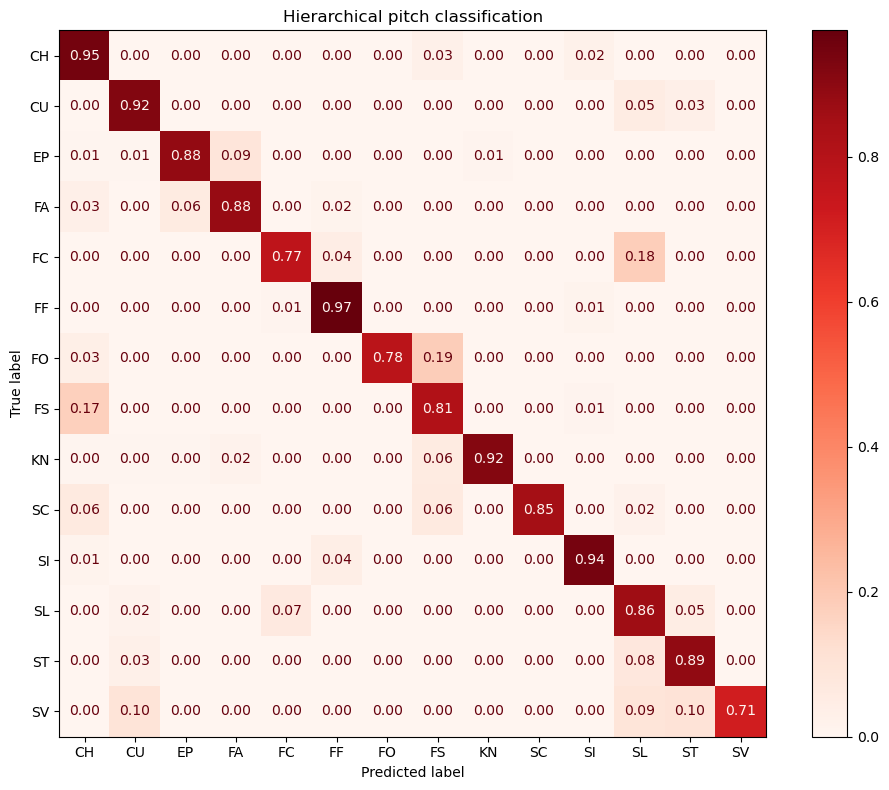

In [18]:
pitch_labels = sorted(np.unique(y_pitch_test))

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_pitch_test,
    final_predictions,
    labels=pitch_labels,
    display_labels=pitch_labels,
    normalize='true',
    cmap='Reds',
    values_format='.2f',
    ax=ax
)

ax.set_title('Hierarchical pitch classification')
plt.tight_layout()
plt.show()

# Tuning

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

# Encode the four group labels
group_encoder = LabelEncoder()
y_group_train_encoded = group_encoder.fit_transform(y_group_train)

print(dict(enumerate(group_encoder.classes_)))

In [ ]:
grid_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(group_encoder.classes_),
    random_state=42,
    n_jobs=1
)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.08],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring={
        'macro_f1': 'f1_macro',
        'weighted_f1': 'f1_weighted',
        'accuracy': 'accuracy'
    },
    refit='macro_f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train, y_group_train_encoded)

print('Best parameters:')
print(grid_search.best_params_)

print('\nBest cross-validation macro F1:')
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

In [ ]:
from sklearn.metrics import classification_report

# Use the same encoder fitted on the training labels
y_group_test_encoded = group_encoder.transform(y_group_test)

predictions_encoded = best_model.predict(X_test).astype(int)

predictions = group_encoder.inverse_transform(predictions_encoded)
actual = group_encoder.inverse_transform(y_group_test_encoded)

print(
    classification_report(
        actual,
        predictions,
        labels=group_encoder.classes_,
        zero_division=0
    )
)

# Refit

In [22]:
group_model, group_encoder = train_xgb_classifier(
    X_train,
    y_group_train,
    n_estimators=500, max_depth=6, learning_rate=0.09, subsample=1, colsample_bytree=0.8
)

In [23]:
group_predictions_encoded = group_model.predict(X_test)

group_predictions = group_encoder.inverse_transform(
    group_predictions_encoded.astype(int)
)

print('CATEGORY MODEL')
print('Accuracy:', accuracy_score(
    y_group_test,
    group_predictions
))

print(classification_report(
    y_group_test,
    group_predictions,
    digits=3
))

CATEGORY MODEL
Accuracy: 0.9678633965191026
              precision    recall  f1-score   support

    Breaking      0.953     0.964     0.958    131332
    Fastball      0.975     0.969     0.972    235823
    Offspeed      0.975     0.975     0.975     56766
        Rare      0.940     0.919     0.930      1544

    accuracy                          0.968    425465
   macro avg      0.961     0.957     0.959    425465
weighted avg      0.968     0.968     0.968    425465



In [24]:
subtype_models = {}
subtype_encoders = {}

for group in pitch_to_group.values():
    # Skip duplicate group names
    if group in subtype_models:
        continue

    group_mask = y_group_train == group

    X_group_train = X_train[group_mask]
    y_group_pitch_train = y_pitch_train[group_mask]

    model, encoder = train_xgb_classifier(
        X_group_train,
        y_group_pitch_train,
        n_estimators=500, max_depth=6, learning_rate=0.09, subsample=1, colsample_bytree=0.8
    )

    subtype_models[group] = model
    subtype_encoders[group] = encoder

    print(
        f'{group}: {len(y_group_pitch_train):,} training pitches, '
        f'classes = {list(encoder.classes_)}'
    )

Offspeed: 227,065 training pitches, classes = ['CH', 'FS']
Breaking: 525,329 training pitches, classes = ['CU', 'SL', 'ST', 'SV']
Fastball: 943,292 training pitches, classes = ['FC', 'FF', 'SI']
Rare: 6,174 training pitches, classes = ['EP', 'FA', 'FO', 'KN', 'SC']


In [25]:
final_predictions = np.empty(
    len(X_test),
    dtype=object
)

for group in subtype_models:
    # Observations routed to this group by Stage 1
    group_mask = group_predictions == group

    if not group_mask.any():
        continue

    model = subtype_models[group]
    encoder = subtype_encoders[group]

    subtype_predictions_encoded = model.predict(
        X_test[group_mask]
    )

    subtype_predictions = encoder.inverse_transform(
        subtype_predictions_encoded.astype(int)
    )

    final_predictions[group_mask] = subtype_predictions

In [26]:
print('FINAL HIERARCHICAL MODEL')
print('Accuracy:', accuracy_score(
    y_pitch_test,
    final_predictions
))

print(classification_report(
    y_pitch_test,
    final_predictions,
    digits=3,
    zero_division=0
))

FINAL HIERARCHICAL MODEL
Accuracy: 0.9161740683722516
              precision    recall  f1-score   support

          CH      0.927     0.946     0.936     44467
          CU      0.939     0.917     0.928     36231
          EP      0.860     0.883     0.871       418
          FA      0.884     0.879     0.881       527
          FC      0.812     0.772     0.791     33565
          FF      0.968     0.974     0.971    135976
          FO      0.873     0.780     0.824       291
          FS      0.876     0.810     0.842     12299
          KN      0.934     0.916     0.925       261
          SC      1.000     0.851     0.920        47
          SI      0.950     0.942     0.946     66282
          SL      0.846     0.862     0.854     65337
          ST      0.845     0.889     0.867     27852
          SV      0.876     0.708     0.783      1912

    accuracy                          0.916    425465
   macro avg      0.899     0.866     0.881    425465
weighted avg      0.916   

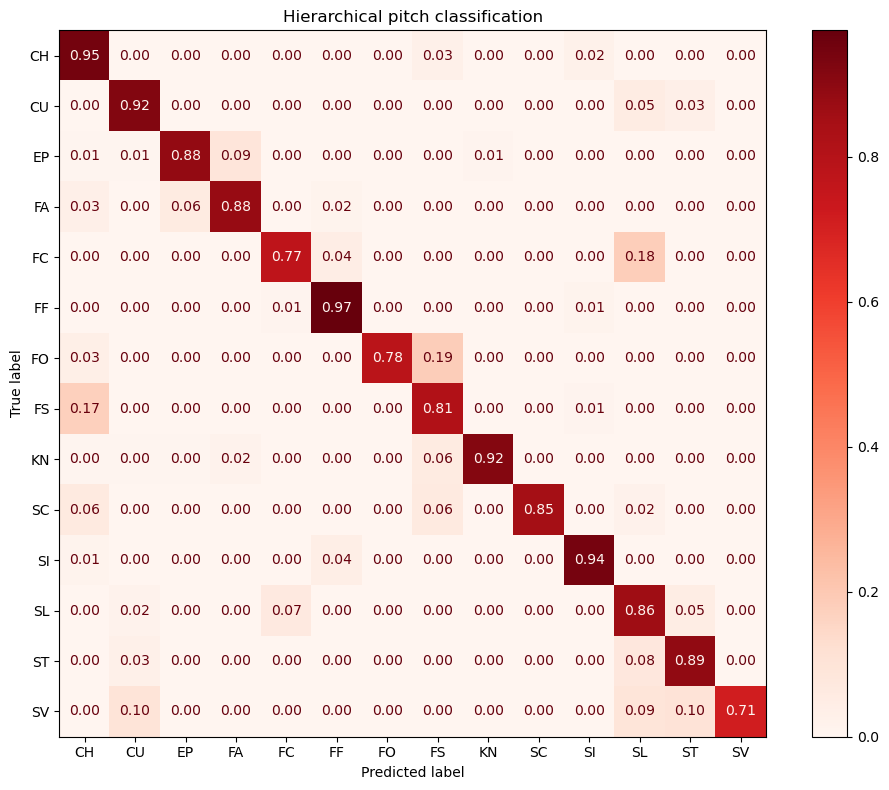

In [27]:
pitch_labels = sorted(np.unique(y_pitch_test))

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_pitch_test,
    final_predictions,
    labels=pitch_labels,
    display_labels=pitch_labels,
    normalize='true',
    cmap='Reds',
    values_format='.2f',
    ax=ax
)

ax.set_title('Hierarchical pitch classification')
plt.tight_layout()
plt.show()